In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score


In [2]:
df = pd.read_csv('/content/Mall_Customers.csv')

In [4]:
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

In [5]:
features = df[['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

In [7]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [8]:
wcss = []

for  k in range(1,11):
  Kmeans = KMeans(n_clusters= k, random_state=42, n_init = 10)
  Kmeans.fit(scaled_features)
  wcss.append(Kmeans.inertia_)


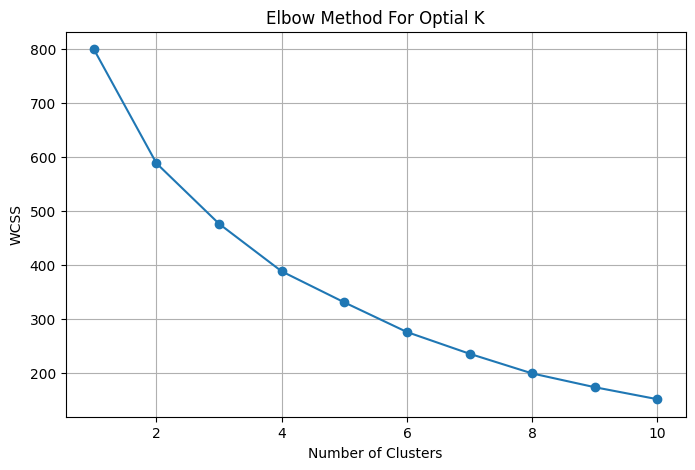

In [10]:
plt.figure(figsize = (8,5))
plt.plot(range(1,11), wcss, marker = 'o')
plt.title('Elbow Method For Optial K')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [13]:
Kmeans = KMeans(n_clusters= 5, random_state=42, n_init = 10)
label = Kmeans.fit_predict(scaled_features)
df['Cluster'] = label

In [15]:
silhouette = silhouette_score(scaled_features, label)
calinski = calinski_harabasz_score(scaled_features, label)
davies = davies_bouldin_score(scaled_features, label)

print("Silhouette Score:", silhouette)
print("Calinski-Harabasz Score:", calinski)
print("Davies-Bouldin Score:", davies)

Silhouette Score: 0.3040600988258827
Calinski-Harabasz Score: 68.96456847863874
Davies-Bouldin Score: 1.1672300848200368


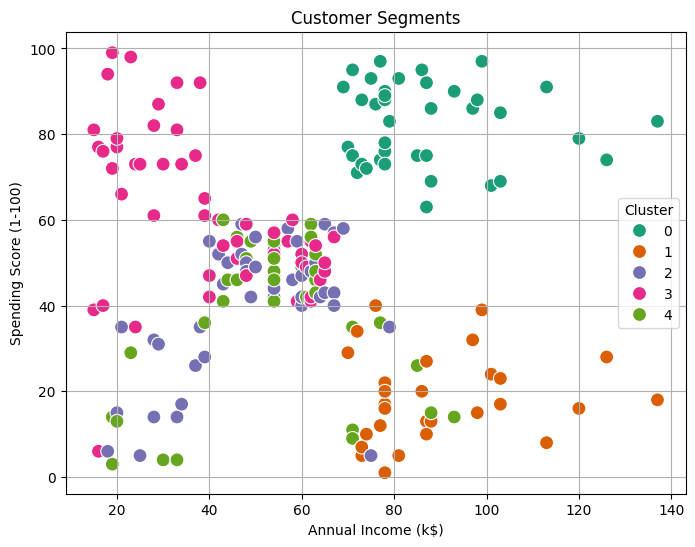

In [20]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='Annual Income (k$)', y='Spending Score (1-100)',
    hue='Cluster', palette='Dark2', s=100
)
plt.title('Customer Segments')
plt.grid(True)
plt.show()